# Regression V2: Baselines and Boosting Models

This report compares frozen family Candidates on the fixed Development Validation rows. Validation supports model development; it is not an independent final evaluation.

## 1. Objective and scope

We compare two transparent baselines, Lasso, HistGradientBoosting, CatBoost, LightGBM, and XGBoost. No Deep model, final ensemble, or final article model is created here.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
REPORTS = ROOT / "outputs" / "reports"
candidate = pd.read_csv(REPORTS / "prompt2_candidate_results.csv")
comparison = pd.read_csv(REPORTS / "prompt2_family_comparison.csv")
lender = pd.read_csv(REPORTS / "prompt2_lender_ablation.csv")
design = json.loads((REPORTS / "prompt2_frozen_design.json").read_text(encoding="utf-8"))
winners = json.loads((REPORTS / "prompt2_family_winners.json").read_text(encoding="utf-8"))
runtime = json.loads((REPORTS / "prompt2_runtime.json").read_text(encoding="utf-8"))
prediction_manifest = json.loads((REPORTS / "prompt2_prediction_manifest.json").read_text(encoding="utf-8"))
model_manifest = json.loads((REPORTS / "prompt2_model_manifest.json").read_text(encoding="utf-8"))
print("Saved-artifact report loaded. Model and preprocessing fit count in this notebook: 0")

Saved-artifact report loaded. Model and preprocessing fit count in this notebook: 0


## 2. Prompt 1B handoff

Prompt 1B passed before modeling. The Development file and its saved attestations were validated again. Raw and IID access remained zero.

In [2]:
handoff = {
    "Prompt 1B status": "PASS",
    "Development SHA-256": design["development_source"]["sha256"],
    "Raw access count": runtime["raw_access_count"],
    "IID feature access count": runtime["iid_feature_access_count"],
    "IID target access count": runtime["iid_target_access_count"],
}
display(pd.DataFrame([handoff]))

,Prompt 1B status,Development SHA-256,Raw access count,IID feature access count,IID target access count
0,PASS,0ed232397be3ec4de1483c594954dce7b4704b375ca295...,0,0,0


## 3. Development Train and Validation roles

All Candidates use the same 400,000 Train rows and the same 100,000 Validation rows. The roles were not recreated.

In [3]:
display(pd.DataFrame([{
    "Development rows": design["development_source"]["row_count"],
    "Train rows": design["development_source"]["role_counts"]["train"],
    "Validation rows": design["development_source"]["role_counts"]["validation"],
    "Train/Validation overlap": design["development_source"]["checks"]["train_validation_overlap"],
}]))

,Development rows,Train rows,Validation rows,Train/Validation overlap
0,500000,400000,100000,0


## 4. Feature contracts

Primary selection excludes sensitive fields and lender identity. The matched lender diagnostic adds only `respondent_id`. Lasso uses a compact feature pack.

In [4]:
contracts = design["feature_contracts"]
display(pd.DataFrame([
    {"contract": "main_without_sensitive_without_lender", "feature_count": len(contracts["main_without_sensitive_without_lender"]), "respondent_id": False},
    {"contract": "main_without_sensitive_with_lender", "feature_count": len(contracts["main_without_sensitive_with_lender"]), "respondent_id": True},
    {"contract": "linear_compact_v2", "feature_count": len(contracts["linear_compact_v2"]), "respondent_id": False},
]))

,contract,feature_count,respondent_id
0,main_without_sensitive_without_lender,35,False
1,main_without_sensitive_with_lender,36,True
2,linear_compact_v2,31,False


## 5. Metric definitions

MAE is primary. Supporting metrics are on the original target scale, in thousands of U.S. dollars. Signed error is prediction minus target; negative values mean underprediction. Tail groups use fixed Validation targets only.

In [5]:
display(pd.DataFrame({"metric": design["metrics"]}))

,metric
0,mae
1,rmse
2,r2
3,rmsle
4,median_absolute_error
5,p90_absolute_error
6,mean_signed_error
7,negative_prediction_count
8,negative_prediction_rate
9,top_decile_mae


## 6. Train mean and median baselines

The constants come only from Train targets. They provide simple reference levels.

In [6]:
baseline_view = comparison[comparison["family"].isin(["train_mean", "train_median"])][["family", "mae", "rmse", "r2", "mean_signed_error"]]
display(baseline_view.style.format({"mae":"{:.3f}", "rmse":"{:.3f}", "r2":"{:.4f}", "mean_signed_error":"{:.3f}"}))

,family,mae,rmse,r2,mean_signed_error
5,train_median,129.898,231.967,-0.0425,-46.836
6,train_mean,136.098,227.192,-0.0000,0.869


## 7. Lasso Candidates

The frozen Lasso definitions were evaluated without adding adaptive Candidates.

In [7]:
view = candidate[candidate["family"].eq("lasso")][["candidate_name", "target_mode", "status", "mae", "rmse", "top_decile_mae", "mean_signed_error", "fitted_iterations", "fit_time_seconds"]]
display(view.style.format({"mae":"{:.3f}", "rmse":"{:.3f}", "top_decile_mae":"{:.3f}", "mean_signed_error":"{:.3f}", "fit_time_seconds":"{:.2f}"}, na_rep="—"))

,candidate_name,target_mode,status,mae,rmse,top_decile_mae,mean_signed_error,fitted_iterations,fit_time_seconds
0,lasso_log1p_anchor,log1p,COMPLETE,70.348,137.513,228.341,-18.245,538,26.60
1,lasso_raw_anchor,raw,COMPLETE,83.260,161.599,223.317,1.159,5000,281.30


## 8. HistGradientBoosting Candidates

The frozen HistGradientBoosting definitions were evaluated without adding adaptive Candidates.

In [8]:
view = candidate[candidate["family"].eq("histgradientboosting")][["candidate_name", "target_mode", "status", "mae", "rmse", "top_decile_mae", "mean_signed_error", "fitted_iterations", "fit_time_seconds"]]
display(view.style.format({"mae":"{:.3f}", "rmse":"{:.3f}", "top_decile_mae":"{:.3f}", "mean_signed_error":"{:.3f}", "fit_time_seconds":"{:.2f}"}, na_rep="—"))

,candidate_name,target_mode,status,mae,rmse,top_decile_mae,mean_signed_error,fitted_iterations,fit_time_seconds
2,hgb_log1p_l1,log1p,COMPLETE,64.137,129.548,199.632,-8.953,300,8.30
3,hgb_raw_l1,raw,COMPLETE,64.841,131.105,200.068,-8.392,300,8.20


## 9. CatBoost Candidates

The frozen CatBoost definitions were evaluated without adding adaptive Candidates.

In [9]:
view = candidate[candidate["family"].eq("catboost")][["candidate_name", "target_mode", "status", "mae", "rmse", "top_decile_mae", "mean_signed_error", "fitted_iterations", "fit_time_seconds"]]
display(view.style.format({"mae":"{:.3f}", "rmse":"{:.3f}", "top_decile_mae":"{:.3f}", "mean_signed_error":"{:.3f}", "fit_time_seconds":"{:.2f}"}, na_rep="—"))

,candidate_name,target_mode,status,mae,rmse,top_decile_mae,mean_signed_error,fitted_iterations,fit_time_seconds
4,cat_log1p_rmse_anchor,log1p,COMPLETE,63.141,126.285,203.815,-15.311,2000,688.35
5,cat_raw_rmse,raw,COMPLETE,69.156,131.235,201.875,-0.369,202,106.62
6,cat_raw_mae,raw,COMPLETE,62.661,126.795,194.786,-7.755,2000,988.51


## 10. LightGBM Candidates

The frozen LightGBM definitions were evaluated without adding adaptive Candidates.

In [10]:
view = candidate[candidate["family"].eq("lightgbm")][["candidate_name", "target_mode", "status", "mae", "rmse", "top_decile_mae", "mean_signed_error", "fitted_iterations", "fit_time_seconds"]]
display(view.style.format({"mae":"{:.3f}", "rmse":"{:.3f}", "top_decile_mae":"{:.3f}", "mean_signed_error":"{:.3f}", "fit_time_seconds":"{:.2f}"}, na_rep="—"))

,candidate_name,target_mode,status,mae,rmse,top_decile_mae,mean_signed_error,fitted_iterations,fit_time_seconds
7,lgb_raw_l2_anchor,raw,COMPLETE,67.828,128.155,196.555,0.723,145,9.31
8,lgb_raw_l1,raw,COMPLETE,63.296,125.698,195.461,-7.098,2000,47.24
9,lgb_raw_huber,raw,COMPLETE,103.508,201.446,406.961,-17.873,2000,70.00


## 11. XGBoost Candidates

The frozen XGBoost definitions were evaluated without adding adaptive Candidates.

In [11]:
view = candidate[candidate["family"].eq("xgboost")][["candidate_name", "target_mode", "status", "mae", "rmse", "top_decile_mae", "mean_signed_error", "fitted_iterations", "fit_time_seconds"]]
display(view.style.format({"mae":"{:.3f}", "rmse":"{:.3f}", "top_decile_mae":"{:.3f}", "mean_signed_error":"{:.3f}", "fit_time_seconds":"{:.2f}"}, na_rep="—"))

,candidate_name,target_mode,status,mae,rmse,top_decile_mae,mean_signed_error,fitted_iterations,fit_time_seconds
10,xgb_log1p_l2_anchor,log1p,COMPLETE,63.243,126.089,202.854,-14.759,1995,331.09
11,xgb_raw_l1,raw,COMPLETE,63.434,127.111,195.019,-6.409,1999,359.66
12,xgb_raw_pseudohuber,raw,COMPLETE,65.376,134.903,202.186,-8.938,2000,342.59


## 12. Family-selection rule

Within each family, the rule starts with lowest MAE. Near ties use RMSE, then top-decile MAE, followed by fitted iterations, model size, fit time, and the simpler target mode.

In [12]:
display(pd.DataFrame([design['selection_rule']]))

,primary,mae_relative_tie,second,rmse_relative_tie,third,final
0,lowest Validation MAE,0.0025,lower RMSE,0.0025,lower top-decile MAE,"[fewer fitted iterations, smaller model size, ..."


## 13. Selected family representatives

One no-lender representative is frozen for every fitted family. These are inputs to later work, not a final model decision.

In [13]:
winner_table = pd.DataFrame([{
    "family": family,
    "model_id": item["candidate_id"],
    "target_mode": item["target_mode"],
    "MAE": item["mae"],
    "RMSE": item["rmse"],
    "top-decile MAE": item["top_decile_mae"],
} for family, item in winners["winners"].items()])
display(winner_table.style.format({"MAE":"{:.3f}", "RMSE":"{:.3f}", "top-decile MAE":"{:.3f}"}))

,family,model_id,target_mode,MAE,RMSE,top-decile MAE
0,lasso,lasso_log1p_anchor__8c42e8499ad0,log1p,70.348,137.513,228.341
1,histgradientboosting,hgb_log1p_l1__b71d4c769e8e,log1p,64.137,129.548,199.632
2,catboost,cat_raw_mae__3e13a9b27727,raw,62.661,126.795,194.786
3,lightgbm,lgb_raw_l1__64ec65b8e75e,raw,63.296,125.698,195.461
4,xgboost,xgb_log1p_l2_anchor__311ad287a6aa,log1p,63.243,126.089,202.854


## 14. Common Validation leaderboard

This table compares all no-lender family representatives with the two Train-only constants on the same Validation rows.

,validation_rank_by_mae,family,target_mode,mae,rmse,r2,rmsle,top_decile_mae
0,1,catboost,raw,62.661,126.795,0.6885,0.3972,194.786
1,2,xgboost,log1p,63.243,126.089,0.6920,0.3830,202.854
2,3,lightgbm,raw,63.296,125.698,0.6939,0.4239,195.461
3,4,histgradientboosting,log1p,64.137,129.548,0.6749,0.3959,199.632
4,5,lasso,log1p,70.348,137.513,0.6336,0.4333,228.341
5,6,train_median,raw,129.898,231.967,-0.0425,0.8886,507.550
6,7,train_mean,raw,136.098,227.192,-0.0000,0.9368,459.845


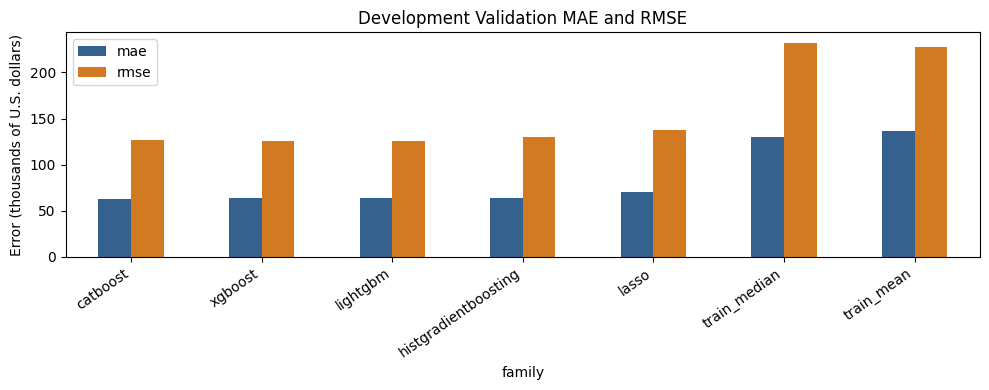

In [14]:
leader = comparison[["validation_rank_by_mae", "family", "target_mode", "mae", "rmse", "r2", "rmsle", "top_decile_mae"]]
display(leader.style.format({"mae":"{:.3f}", "rmse":"{:.3f}", "r2":"{:.4f}", "rmsle":"{:.4f}", "top_decile_mae":"{:.3f}"}))
ax = leader.set_index("family")[["mae", "rmse"]].plot(kind="bar", figsize=(10, 4), color=["#35618f", "#d17a22"])
ax.set_ylabel("Error (thousands of U.S. dollars)")
ax.set_title("Development Validation MAE and RMSE")
plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()

## 15. Tail-error comparison

Top-decile MAE focuses on the largest fixed Validation targets. It is descriptive and does not change the frozen split.

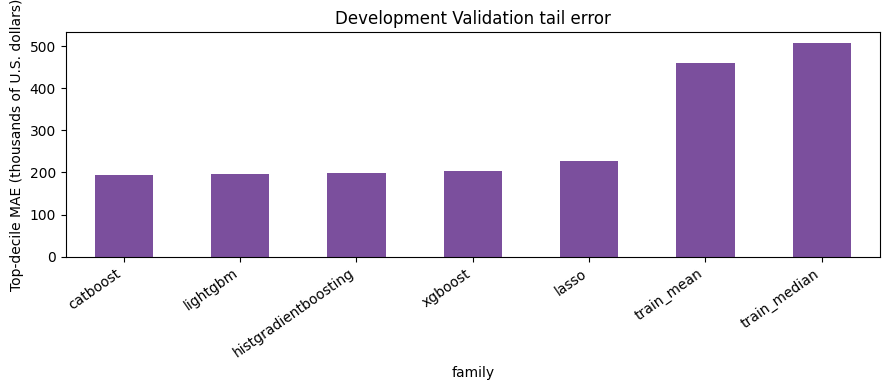

,family,top_decile_mae,top_five_percent_mae,top_decile_underprediction_rate,top_five_percent_underprediction_rate
0,catboost,194.785914,279.640881,0.786478,0.816424
1,xgboost,202.854094,286.992072,0.809947,0.833167
2,lightgbm,195.460670,280.182225,0.788775,0.821407
3,histgradientboosting,199.631925,287.125002,0.796365,0.836157
4,lasso,228.340719,325.416109,0.841906,0.876022
5,train_median,507.550185,711.472394,1.000000,1.000000
6,train_mean,459.844752,663.766961,1.000000,1.000000


In [15]:
ax = comparison.sort_values("top_decile_mae").plot(x="family", y="top_decile_mae", kind="bar", legend=False, figsize=(9, 4), color="#7b4f9d")
ax.set_ylabel("Top-decile MAE (thousands of U.S. dollars)")
ax.set_title("Development Validation tail error")
plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()
display(comparison[["family", "top_decile_mae", "top_five_percent_mae", "top_decile_underprediction_rate", "top_five_percent_underprediction_rate"]])

## 16. Signed-error comparison

The zero line represents no average signed bias. Distance from zero is the comparison rule.

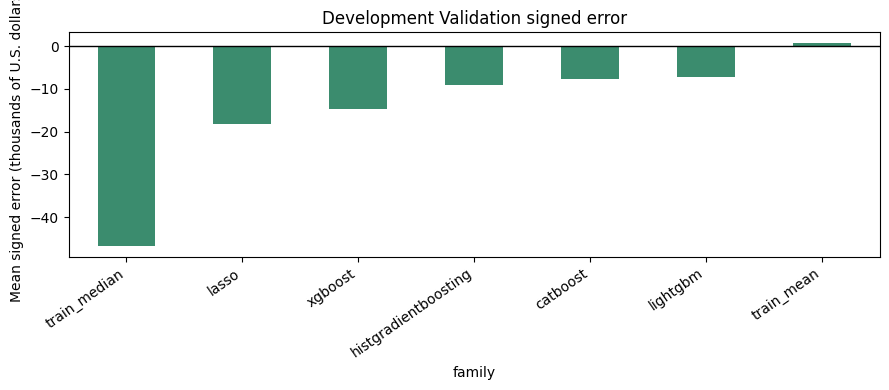

In [16]:
signed = comparison.sort_values("mean_signed_error")
ax = signed.plot(x="family", y="mean_signed_error", kind="bar", legend=False, figsize=(9, 4), color="#3b8c6e")
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Mean signed error (thousands of U.S. dollars)")
ax.set_title("Development Validation signed error")
plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()

## 17. Runtime and model-size comparison

Heavy fits ran sequentially with at most four model threads. Peak memory is a bounded parent-process observation.

,family,mae,fit_time_seconds,bundle_size_bytes
0,catboost,62.660954,988.511760,49551805
1,xgboost,63.243238,331.091251,2940432
2,lightgbm,63.296230,47.244942,3447139
3,histgradientboosting,64.137294,8.304041,625322
4,lasso,70.348448,26.601988,6007


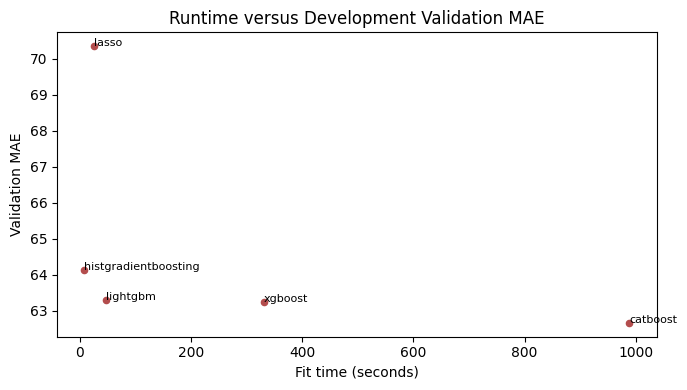

In [17]:
runtime_view = comparison[~comparison["family"].isin(["train_mean", "train_median"])][["family", "mae", "fit_time_seconds", "bundle_size_bytes"]]
display(runtime_view)
ax = runtime_view.plot.scatter(x="fit_time_seconds", y="mae", figsize=(7, 4), color="#b34d4d")
for _, row in runtime_view.iterrows():
    ax.annotate(row["family"], (row["fit_time_seconds"], row["mae"]), fontsize=8)
ax.set_xlabel("Fit time (seconds)"); ax.set_ylabel("Validation MAE")
ax.set_title("Runtime versus Development Validation MAE"); plt.tight_layout(); plt.show()

## 18. Controlled lender ablation

Each boosting comparison adds only `respondent_id` and keeps the selected target mode, objective, settings, seed, and fitted iteration count fixed. This is an accuracy diagnostic, not fairness or causal evidence.

In [18]:
display(lender)

,family,without_lender_model_id,with_lender_model_id,fixed_target_mode,fixed_fitted_iterations,only_added_feature,without_lender_mae,with_lender_mae,mae_difference_with_minus_without,without_lender_rmse,...,without_lender_top_decile_mae,with_lender_top_decile_mae,top_decile_mae_difference_with_minus_without,without_lender_mean_signed_error,with_lender_mean_signed_error,absolute_mean_signed_error_difference,fit_time_difference_seconds,prediction_correlation,mean_absolute_prediction_difference,interpretation_scope
0,catboost,cat_raw_mae__3e13a9b27727,selected_catboost_with_lender__7199e99ed7ee,raw,2000,respondent_id,62.660954,62.158423,-0.502531,126.795248,...,194.785914,193.817364,-0.968550,-7.755353,-7.905064,0.149711,57.764119,0.996886,7.898233,Accuracy-only diagnostic; not fairness or caus...
1,lightgbm,lgb_raw_l1__64ec65b8e75e,selected_lightgbm_with_lender__ffaaa71dadd1,raw,2000,respondent_id,63.296230,62.970659,-0.325571,125.698421,...,195.460670,194.627355,-0.833315,-7.097795,-7.336633,0.238838,-19.457531,0.996700,7.223850,Accuracy-only diagnostic; not fairness or caus...
2,xgboost,xgb_log1p_l2_anchor__311ad287a6aa,selected_xgboost_with_lender__9086d5ccb98a,log1p,1995,respondent_id,63.243238,62.786136,-0.457102,126.088854,...,202.854094,201.075219,-1.778875,-14.758532,-14.668891,-0.089641,-304.415085,0.994252,8.766554,Accuracy-only diagnostic; not fairness or caus...


## 19. Saved bundles and prediction artifacts

Eight complete model bundles and ten aligned Validation prediction files passed reload and integrity checks.

In [19]:
display(pd.DataFrame(model_manifest["bundles"])[["key", "model_id", "feature_contract", "target_mode", "size_bytes", "status"]])
display(pd.DataFrame(prediction_manifest["artifacts"])[["key", "rows", "row_order_equal", "target_equal", "finite_predictions", "status"]])

,key,model_id,feature_contract,target_mode,size_bytes,status
0,lasso,lasso_log1p_anchor__8c42e8499ad0,linear_compact_v2,log1p,6007,PASS
1,histgradientboosting,hgb_log1p_l1__b71d4c769e8e,main_without_sensitive_without_lender,log1p,625322,PASS
2,catboost,cat_raw_mae__3e13a9b27727,main_without_sensitive_without_lender,raw,49551805,PASS
3,lightgbm,lgb_raw_l1__64ec65b8e75e,main_without_sensitive_without_lender,raw,3447139,PASS
4,xgboost,xgb_log1p_l2_anchor__311ad287a6aa,main_without_sensitive_without_lender,log1p,2940432,PASS
5,catboost_with_lender,selected_catboost_with_lender__7199e99ed7ee,main_without_sensitive_with_lender,raw,87793698,PASS
6,lightgbm_with_lender,selected_lightgbm_with_lender__ffaaa71dadd1,main_without_sensitive_with_lender,raw,3483983,PASS
7,xgboost_with_lender,selected_xgboost_with_lender__9086d5ccb98a,main_without_sensitive_with_lender,log1p,2962967,PASS


,key,rows,row_order_equal,target_equal,finite_predictions,status
0,train_mean,100000,True,True,True,PASS
1,train_median,100000,True,True,True,PASS
2,lasso,100000,True,True,True,PASS
3,histgradientboosting,100000,True,True,True,PASS
4,catboost,100000,True,True,True,PASS
5,lightgbm,100000,True,True,True,PASS
6,xgboost,100000,True,True,True,PASS
7,catboost_with_lender,100000,True,True,True,PASS
8,lightgbm_with_lender,100000,True,True,True,PASS
9,xgboost_with_lender,100000,True,True,True,PASS


## 20. Verification

The saved bundles predict in clean processes within the required numerical tolerance. Every prediction file uses the same Validation row order and exact target values.

In [20]:
clean = pd.DataFrame([b["clean_process_check"] for b in model_manifest["bundles"]])
display(clean)
print("Maximum clean-process absolute difference:", clean["maximum_absolute_difference"].max())
print("Prediction manifest status:", prediction_manifest["status"])

,bundle_key,bundle_path,sample_rows,row_order_identical,finite_predictions,maximum_absolute_difference,status
0,lasso,outputs/models/prompt2/selected_lasso.joblib,1000,True,True,0.0,PASS
1,histgradientboosting,outputs/models/prompt2/selected_histgradientbo...,1000,True,True,0.0,PASS
2,catboost,outputs/models/prompt2/selected_catboost_witho...,1000,True,True,0.0,PASS
3,lightgbm,outputs/models/prompt2/selected_lightgbm_witho...,1000,True,True,0.0,PASS
4,xgboost,outputs/models/prompt2/selected_xgboost_withou...,1000,True,True,0.0,PASS
5,catboost_with_lender,outputs/models/prompt2/selected_catboost_with_...,1000,True,True,0.0,PASS
6,lightgbm_with_lender,outputs/models/prompt2/selected_lightgbm_with_...,1000,True,True,0.0,PASS
7,xgboost_with_lender,outputs/models/prompt2/selected_xgboost_with_l...,1000,True,True,0.0,PASS


Maximum clean-process absolute difference: 0.0
Prediction manifest status: PASS


## 21. Limitations

Development Validation is reused for Candidate selection and early stopping where specified. It is not an unbiased final evaluation. Resource telemetry is bounded, and lender identity results cannot show cause or fairness.

## 22. Prompt 3 handoff

The selected family bundles and exact aligned Validation predictions are ready for the next authorized Prompt only after final review and `PROMPT2_READY.json` PASS. This notebook does not start Prompt 3.